## Measure Day 

**Date: 05/10/2026**  
**Time: 13.45 - 17.45**  

**Research question:**  How does the initial gravitational potential energy $E_0$ of a double pendulum affect the finite-time exponential divergence rate $\lambda$  of nearby trajectories?  
**Assumptions:** The initial kinetic energy of the double pendulum is neglected, because the pendulum is released from rest.  
**Hypothesis**:  At lower initial gravitational potential energy, the double pendulum remains close to the small-angle regime where its equations of motion are lineair and the motion approximately harmonic. As this initial energy increases, the small angle approximation becomes invalid and nonlineair effects become more important. We therefore expect finite time exponential divergence rate to increase with initial gravitational potential energy.  
**Measuring Setup:**  
**Measuring Plan:**  
- Measure the pendulums lengths L1 and L2
- measure the pendulum masses m1 and m2
- mark the center of masses with distinguishable red and green markers. 
- place the camera parallel to the plane of motion
- fix the camera for the entire experiment and note its settings
- test that the motion of the pendulum stays inside the video frame  

Repeat the following measurements for initial angles of $\theta_1$ = 10 $^{\circ}$, 20 $^{\circ}$  ,30 $^{\circ}$  ,40 $^{\circ}$  ,50 $^{\circ}$  ,60 $^{\circ}$    and $\theta_2$ = 0 $^{\circ}$

- place the pendulum in the first initial position
- let the pendulum come to rest
- start recording while still holding the pendulum without blocking the markers
- record the release from rest out of this initial condition
- stop the recording. Later, extract the actual initial angles from the first video frames
- place the pendulum in the same initial condition with an increase of $\theta_1$ equal to 3 degrees
- record the release from rest again
- import these files into python
- run the tracking code and check that the markers have been tracked correctly
- repeat all steps with an increase in initial angles  
- *make repeated measurements for each initial state*  
 **Data Analysis Procedure**: 

# Dubbele slinger — van pixels naar $(r,\phi)$, impulsen en $\lambda_{FT}$

Dit notebook bouwt voort op `Pendulum tracking.ipynb` en volgt het stappenplan:

0. **Eenmalig:** first frame uit de eerste video halen (voor kalibratie en pivot)
1. **Parameters & kalibratie** (L1, L2, m1, m2, pixels/m, pivotpositie)
2. **Tracking van de rode en groene marker** → CSV met `x1, y1, x2, y2` in pixels, met een **pop-up** om de tracking te controleren
3. **Pixels → $(r_i, \phi_i)$** met de formules uit de theorie (§10)
4. **Hoeksnelheden, impulsen $p_1, p_2$, energie** → canonieke CSV per opname
5. **$U_0$** van een loslating vanuit stilstand (**loslaatmoment handmatig**)
6. **Twee opnames vergelijken**: $\delta(\tau)$ met **handmatige normalisatiewaarden**, $\ln[\delta/\delta_0]$, lineaire fit over een **handmatig gekozen interval** → $\lambda_{FT}$
7. **`analyse_pair(...)`**: alle stappen voor één paar video's in één functie
8. **$\lambda_{FT}$ vs $U_0$**

Onderaan staat een **test met gesimuleerde data**, zodat je de hele pijplijn kunt controleren zonder video's (en kunt zien wat je theoretisch mag verwachten).

**Coördinaten:** oorsprong in het ophangpunt, $y$ omhoog (beeld-$y$ wijst omlaag, dus die wordt omgeklapt).
$\phi_i$ is de hoek van staaf $i$ t.o.v. de neerwaartse verticaal, positief richting $+x$. $r_i$ is de lengte van staaf $i$ zoals gemeten in het beeld — die hoort constant te zijn ($\approx L_i$) en is dus een goede kwaliteitscontrole op kalibratie en tracking.

**Handmatige keuzes** (bewust niet automatisch): het loslaatmoment per opname, de normalisatieschalen van $\delta$, en het fitinterval voor $\lambda_{FT}$. Elk daarvan kun je met een plot bepalen en variëren.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.integrate import solve_ivp

## 0. Eenmalig: first frame exporteren
Haal het eerste frame uit de **eerste video** van de meetserie. Open de PNG in Paint/ImageJ om de pixelcoördinaten van de pivot en van twee punten op de liniaal af te lezen (kalibratie, zie sectie 1). Het frame wordt op de originele pixelresolutie opgeslagen.

Je hoeft dit maar één keer te doen, zolang camera en opstelling niet veranderen.

In [2]:
def export_first_frame(video_path, output_png=None, dpi=300, show=False):
    """
    Exporteer het eerste frame van een video als PNG op de originele pixelresolutie.

    video_path : pad naar de video
    output_png : uitvoerpad; default <videonaam>_first_frame.png
    dpi        : alleen metadata in de PNG (verandert niets aan het aantal pixels)
    show       : True -> toon het frame ook met matplotlib-assen in pixels
                 (handig: met de muis over het beeld zie je de pixelcoördinaten)
    """
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    if output_png is None:
        output_png = video_path.with_name(video_path.stem + "_first_frame.png")
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    success, frame = cap.read()
    cap.release()
    if not success or frame is None:
        raise RuntimeError("Could not read the first frame from the video.")

    height, width = frame.shape[:2]
    if not cv2.imwrite(str(output_png), frame, [cv2.IMWRITE_PNG_COMPRESSION, 3]):
        raise RuntimeError(f"Could not save PNG: {output_png}")

    # OpenCV schrijft geen betrouwbare DPI-metadata, dus voeg die toe met Pillow.
    try:
        from PIL import Image
        with Image.open(output_png) as image:
            image.save(output_png, dpi=(dpi, dpi))
    except ImportError:
        print("Pillow is not installed, so DPI metadata was not added (pip install pillow).")

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels, DPI metadata: {dpi}")

    if show:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.xlabel("x (pixels)"); plt.ylabel("y (pixels)")
        plt.title("first frame (pixelcoördinaten)")
        plt.show()
    return output_png

In [3]:
# Eenmalig uitvoeren (pas de bestandsnamen aan):
# export_first_frame(video_path="video_10deg_A.mp4",
#                    output_png="first_frame.png",
#                    show=True)

## 1. Parameters en kalibratie
Vul hier jullie gemeten waarden in (met onzekerheid in je logboek). De pivotpositie en `px_per_m` haal je uit de first-frame PNG (bijv. in Paint/ImageJ de pixelcoördinaten van de pivot en van twee punten op de liniaal aflezen).

In [49]:
g = 9.81          # m/s^2

# --- GEMETEN WAARDEN (aanpassen!) ---
L1 = 12.8e-2        # m, effectieve lengte arm 1 (pivot -> marker 1)
L2 = 7e-2        # m, effectieve lengte arm 2 (marker 1 -> marker 2)
m1 = 270.5e-3        # kg
m2 = 200.2e-3        # kg

# Kalibratie uit first frame
ruler_p1 = (962,157)     # pixelcoördinaten van een punt op de liniaal
ruler_p2 = (1269,619)    # pixelcoördinaten van een tweede punt
ruler_dist_m = L1       # werkelijke afstand tussen die twee punten in m
px_per_m = np.hypot(ruler_p2[0]-ruler_p1[0], ruler_p2[1]-ruler_p1[1]) / ruler_dist_m

pivot_px = (1026, 158)     # (X0, Y0) in pixels

print(f"px_per_m = {px_per_m:.1f}  (= {px_per_m/100:.2f} px/cm)")
print(f"L1 in pixels ≈ {L1*px_per_m:.0f}, L2 in pixels ≈ {L2*px_per_m:.0f}")

px_per_m = 4333.6  (= 43.34 px/cm)
L1 in pixels ≈ 555, L2 in pixels ≈ 303


## 2. Tracking van de **rode en groene marker**
Net als in `Pendulum tracking.ipynb` volgen we per kleur de grootste blob (HSV-drempel, opening/closing, grootste contour, subpixel-centroïde). Twee verschillen met het origineel:

- de twee markers worden in één doorgang gevolgd en direct toegewezen aan de twee scharnieren: **marker 1 = bovenste scharnier** (afstand $L_1$ van de pivot), **marker 2 = onderste massa**. Welke kleur waar zit stel je in met `MARKER1_COLOR` / `MARKER2_COLOR`;
- `process_video_two_markers` toont, net als het origineel, een **pop-up** met links het originele frame en het geannoteerde frame (pivot, arm 1 en arm 2, labels) en eronder de twee maskers.

Bediening van de pop-up: **`q`** sluit het venster (de tracking loopt dan door zonder preview), **spatie** pauzeert (nogmaals spatie of een andere toets = verder).
Controleer vooral bij hoge snelheid en bij kruisingen van de armen of de markers goed gevolgd worden. Kijk naar het frame, niet alleen naar de coördinaten.

In [5]:
# --- Markerkleuren (pas aan als jullie opstelling andersom is) ---
MARKER1_COLOR = "red"      # bovenste scharnier  (pivot -> marker 1 = arm 1)
MARKER2_COLOR = "green"    # onderste massa      (marker 1 -> marker 2 = arm 2)

# HSV-grenzen (zelfde als in Pendulum_tracking.ipynb). Rood loopt rond in HSV, dus twee bereiken.
HSV_RANGES = {
    "red":   [((0, 80, 50), (10, 255, 255)), ((170, 80, 50), (180, 255, 255))],
    "green": [((35, 80, 50), (85, 255, 255))],
}


def detect_marker(frame, color, min_area=10):
    """
    Zoek de grootste blob van `color` ("red" of "green") in een BGR-frame.
    Return (x, y, mask); x, y zijn None als er niets (groot genoeg) gevonden is.
    """
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], np.uint8)
    for lo, hi in HSV_RANGES[color]:
        mask |= cv2.inRange(hsv, np.array(lo), np.array(hi))
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None, mask
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < min_area:
        return None, None, mask
    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask
    return M["m10"] / M["m00"], M["m01"] / M["m00"], mask      # sub-pixel centroid


def annotate_frame(frame, pivot_px, p1, p2, idx, t):
    """Teken pivot, arm 1, arm 2 en labels op een kopie van het frame."""
    ann = frame.copy()
    piv = tuple(int(round(v)) for v in pivot_px)
    cv2.circle(ann, piv, 7, (255, 255, 0), -1)
    last = piv
    for p, col, lab in [(p1, (0, 255, 255), "1"), (p2, (255, 0, 255), "2")]:
        if p is None:
            cv2.putText(ann, f"marker {lab} NOT FOUND", (20, 40 if lab == "1" else 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)
            continue
        q = (int(round(p[0])), int(round(p[1])))
        cv2.line(ann, last, q, (255, 255, 255), 2)
        last = q
        cv2.circle(ann, q, 8, col, -1)
        cv2.putText(ann, f"{lab} ({q[0]}, {q[1]})", (q[0] + 12, q[1] - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2, cv2.LINE_AA)
    cv2.putText(ann, f"frame {idx}  t = {t:.3f} s", (20, ann.shape[0] - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    return ann


def process_video_two_markers(video_path, output_csv, pivot_px,
                              marker1_color=None, marker2_color=None,
                              preview=True, preview_scale=0.4, save_annotated=False):
    """
    Volg de markers in een video en schrijf x1,y1,x2,y2 (pixels) naar een CSV.

    preview=True      : pop-up met origineel | geannoteerd (boven) en maskers (onder).
                        q = sluit pop-up (tracking gaat door), spatie = pauze.
    save_annotated    : schrijf ook <video>_tracked2.mp4 met de annotaties.
    """
    marker1_color = marker1_color or MARKER1_COLOR
    marker2_color = marker2_color or MARKER2_COLOR
    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = None
    if save_annotated:
        out = video_path.with_name(video_path.stem + "_tracked2.mp4")
        writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    win = "Tracking check (q = close, space = pause)"
    rows, i = [], 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        t = i / fps if fps > 0 else np.nan
        x1, y1, mask1 = detect_marker(frame, marker1_color)
        x2, y2, mask2 = detect_marker(frame, marker2_color)
        p1 = (x1, y1) if x1 is not None else None
        p2 = (x2, y2) if x2 is not None else None
        rows.append({"frame": i, "time_s": t,
                     "x1": x1 if p1 else np.nan, "y1": y1 if p1 else np.nan,
                     "x2": x2 if p2 else np.nan, "y2": y2 if p2 else np.nan})

        if writer is not None or preview:
            ann = annotate_frame(frame, pivot_px, p1, p2, i, t)
            if writer is not None:
                writer.write(ann)
            if preview:
                m1 = cv2.cvtColor(mask1, cv2.COLOR_GRAY2BGR)
                m2 = cv2.cvtColor(mask2, cv2.COLOR_GRAY2BGR)
                cv2.putText(m1, f"mask marker 1 ({marker1_color})", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2, cv2.LINE_AA)
                cv2.putText(m2, f"mask marker 2 ({marker2_color})", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 255), 2, cv2.LINE_AA)
                display = np.vstack((np.hstack((frame, ann)), np.hstack((m1, m2))))
                display = cv2.resize(display, None, fx=preview_scale, fy=preview_scale)
                cv2.imshow(win, display)
                key = cv2.waitKey(1) & 0xFF
                if key == ord("q"):
                    preview = False
                    cv2.destroyAllWindows(); cv2.waitKey(1)
                    print(f"Preview gesloten bij frame {i}; tracking gaat door zonder preview.")
                elif key == ord(" "):
                    cv2.waitKey(0)
        i += 1

    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows(); cv2.waitKey(1)

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"Saved {output_csv}: {len(df)} frames, fps = {fps:.2f}")
    print(f"Missende detecties: marker 1 ({marker1_color}) = {df.x1.isna().sum()}, "
          f"marker 2 ({marker2_color}) = {df.x2.isna().sum()}")
    if save_annotated:
        print(f"Geannoteerde video opgeslagen: {out}")
    return df

In [6]:
# Voorbeeld (pas bestandsnamen aan):
# df_px = process_video_two_markers("video_10deg_A.mp4", "video_10deg_A_2markers.csv",
#                                   pivot_px=pivot_px, preview=True, save_annotated=False)

## 3. Pixels → $(r, \phi)$
Met pivot $(X_0, Y_0)$, $y$ omhoog (theorie §10):

$$x_i = \frac{X_i - X_0}{\text{px/m}},\qquad y_i = -\frac{Y_i - Y_0}{\text{px/m}}$$

$$\phi_1 = \operatorname{atan2}(x_1,\,-y_1),\qquad \phi_2 = \operatorname{atan2}(x_2 - x_1,\; y_1 - y_2)$$

$$r_1 = \sqrt{x_1^2+y_1^2},\qquad r_2 = \sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$$

`atan2` springt bij $\pm\pi$ (als een arm over de top gaat). Voor het differentiëren gebruiken we daarom de **ge-unwrapte** hoek.

In [7]:
def pixels_to_polar(df_px, pivot_px, px_per_m):
    X0, Y0 = pivot_px
    df = df_px[["frame", "time_s"]].copy()
    # korte gaten in de tracking lineair opvullen (lange gaten: check je video!)
    pix = df_px[["x1", "y1", "x2", "y2"]].interpolate(limit=3, limit_direction="both")
    x1 = (pix.x1 - X0) / px_per_m;  y1 = -(pix.y1 - Y0) / px_per_m
    x2 = (pix.x2 - X0) / px_per_m;  y2 = -(pix.y2 - Y0) / px_per_m
    df["x1"], df["y1"], df["x2"], df["y2"] = x1, y1, x2, y2
    df["r1"] = np.hypot(x1, y1)
    df["r2"] = np.hypot(x2 - x1, y2 - y1)
    df["phi1"] = np.arctan2(x1, -y1)
    df["phi2"] = np.arctan2(x2 - x1, y1 - y2)
    # unwrap (alleen over geldige stukken)
    for k in ("phi1", "phi2"):
        v = df[k].to_numpy().copy(); ok = ~np.isnan(v)
        v[ok] = np.unwrap(v[ok]); df[k + "_unwrap"] = v
    return df


def plot_polar(df, title=""):
    fig, ax = plt.subplots(2, 2, figsize=(12, 7))
    t = df.time_s
    ax[0, 0].plot(t, df.phi1_unwrap, label=r"$\phi_1$"); ax[0, 0].plot(t, df.phi2_unwrap, label=r"$\phi_2$")
    ax[0, 0].set(xlabel="t (s)", ylabel="hoek (rad)", title=r"$\phi(t)$"); ax[0, 0].legend()
    ax[0, 1].plot(t, df.r1 * 100, label=r"$r_1$"); ax[0, 1].plot(t, df.r2 * 100, label=r"$r_2$")
    ax[0, 1].axhline(L1 * 100, ls="--", c="C0"); ax[0, 1].axhline(L2 * 100, ls=":", c="C1")
    ax[0, 1].set(xlabel="t (s)", ylabel="r (cm)", title=r"$r(t)$ — hoort constant $\approx L$ te zijn"); ax[0, 1].legend()
    ax[1, 0].plot(df.x1 * 100, df.y1 * 100, ".", ms=2, label="massa 1")
    ax[1, 0].plot(df.x2 * 100, df.y2 * 100, ".", ms=2, label="massa 2")
    ax[1, 0].plot(0, 0, "k+", ms=12); ax[1, 0].set_aspect("equal")
    ax[1, 0].set(xlabel="x (cm)", ylabel="y (cm)", title="baan in het vlak"); ax[1, 0].legend()
    # polaire plot van beide armen
    ax[1, 1].remove(); axp = fig.add_subplot(2, 2, 4, projection="polar")
    axp.set_theta_zero_location("S"); axp.set_theta_direction(1)      # 0 = recht naar beneden, + richting +x
    axp.plot(df.phi1, df.r1 * 100, ".", ms=2, label="arm 1")
    axp.plot(df.phi2, df.r2 * 100, ".", ms=2, label="arm 2")
    axp.set_rlim(0, 1.2*max(L1, L2)*100); axp.set_title(r"$(r_i, \phi_i)$"); axp.legend(loc="lower right", fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    print(f"r1 = {df.r1.mean()*100:.2f} ± {df.r1.std()*100:.2f} cm  (L1 = {L1*100:.1f} cm)")
    print(f"r2 = {df.r2.mean()*100:.2f} ± {df.r2.std()*100:.2f} cm  (L2 = {L2*100:.1f} cm)")

## 4. Hoeksnelheden, impulsen en energie
Differentiëren versterkt ruis, dus we gebruiken een Savitzky–Golay-filter (lokale polynoomfit) dat in één keer glad maakt en afleidt. `window` (oneven, in frames) en `poly` zijn analysekeuzes — rapporteer ze en check of $\lambda$ ervan afhangt.

Gegeneraliseerde impulsen (uit $p_i = \partial\mathcal L/\partial\dot\phi_i$, theorie §6):

$$p_1 = (m_1+m_2)L_1^2\dot\phi_1 + m_2L_1L_2\dot\phi_2\cos(\phi_1-\phi_2)$$
$$p_2 = m_2L_2^2\dot\phi_2 + m_2L_1L_2\dot\phi_1\cos(\phi_1-\phi_2)$$

In [8]:
def add_canonical(df, window=11, poly=3):
    dt = np.median(np.diff(df.time_s))
    out = df.copy()
    for k in ("phi1", "phi2"):
        v = out[k + "_unwrap"].interpolate(limit_direction="both").to_numpy()
        out[k + "_s"] = savgol_filter(v, window, poly)                       # gladgestreken hoek
        out["w" + k[-1]] = savgol_filter(v, window, poly, deriv=1, delta=dt)  # dphi/dt
    p1s, p2s, w1, w2 = out.phi1_s, out.phi2_s, out.w1, out.w2
    c = np.cos(p1s - p2s)
    out["p1"] = (m1 + m2) * L1**2 * w1 + m2 * L1 * L2 * w2 * c
    out["p2"] = m2 * L2**2 * w2 + m2 * L1 * L2 * w1 * c
    out["T"] = 0.5*(m1+m2)*L1**2*w1**2 + 0.5*m2*L2**2*w2**2 + m2*L1*L2*w1*w2*c
    # U t.o.v. de evenwichtsstand (beide armen recht naar beneden) -> U >= 0
    out["U"] = (m1+m2)*g*L1*(1-np.cos(p1s)) + m2*g*L2*(1-np.cos(p2s))
    out["E"] = out["T"] + out["U"]
    return out


def plot_canonical(df, title=""):
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
    t = df.time_s
    ax[0].plot(t, df.w1, label=r"$\dot\phi_1$"); ax[0].plot(t, df.w2, label=r"$\dot\phi_2$")
    ax[0].set(xlabel="t (s)", ylabel="rad/s"); ax[0].legend()
    ax[1].plot(t, df.p1, label="$p_1$"); ax[1].plot(t, df.p2, label="$p_2$")
    ax[1].set(xlabel="t (s)", ylabel="kg m²/s"); ax[1].legend()
    ax[2].plot(t, df["T"], label="T"); ax[2].plot(t, df["U"], label="U"); ax[2].plot(t, df["E"], "k", label="E")
    ax[2].set(xlabel="t (s)", ylabel="J", title="energie (E hoort ~constant, langzaam dalend)"); ax[2].legend(fontsize=8)
    ax[3].plot(np.angle(np.exp(1j*df.phi1_s)), df.p1, ".", ms=1, label=r"$(\phi_1,p_1)$")
    ax[3].plot(np.angle(np.exp(1j*df.phi2_s)), df.p2, ".", ms=1, label=r"$(\phi_2,p_2)$")
    ax[3].set(xlabel=r"$\phi$ (rad)", ylabel="p", title="faseruimte-projecties"); ax[3].legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()


def export_canonical(df, path):
    cols = ["time_s", "phi1_s", "phi2_s", "w1", "w2", "p1", "p2", "E"]
    df[cols].rename(columns={"phi1_s": "phi1", "phi2_s": "phi2"}).to_csv(path, index=False)
    print("Canonieke CSV opgeslagen:", path)

In [9]:
# Voorbeeld voor één opname:
# df_px  = pd.read_csv("video_10deg_A_2markers.csv")
# df_pol = pixels_to_polar(df_px, pivot_px, px_per_m)
# plot_polar(df_pol, "opname A")
# df_can = add_canonical(df_pol, window=11, poly=3)
# plot_canonical(df_can, "opname A")
# export_canonical(df_can, "A_canonical.csv")

## 5. Loslaatmoment (handmatig) en initiële potentiële energie $U_0$
Bij loslaten vanuit stilstand is $T_0 = 0$, dus $E = U_0$. We nemen $U = 0$ in de evenwichtsstand (dan is $U_0 \ge 0$ en intuïtief: 'hoeveel energie zit erin'):

$$U_0 = (m_1+m_2)\,g\,L_1(1-\cos\phi_{1,0}) + m_2\,g\,L_2(1-\cos\phi_{2,0})$$

Handig om ook dimensieloos te maken, bijv. $U_0 / U_{max}$ met $U_{max} = 2(m_1+m_2)gL_1 + 2m_2gL_2$ (beide armen recht omhoog).

**Het loslaatmoment `t_release` geef je zelf in (in seconden).** Er is geen automatische detectie meer. Gebruik `plot_release_check(df)`: de plot toont $\phi_1(t)$, $\phi_2(t)$ (ruwe, ongefilterde hoeken) en $\dot\phi_1,\dot\phi_2$ met een extra as in frames. Kies `t_release` als het **laatste moment waarop de slinger nog stilstaat**, dus net vóór de hoek van het plateau afbuigt. (De hoeksnelheid is met Savitzky–Golay gladgestreken en loopt daardoor iets voor op de werkelijke start; vertrouw voor het moment van afbuigen op de hoekplot.) Teken je keuze in met `plot_release_check(df, t_release=..., t_range=(..., ...))` en pas aan tot het klopt.

De beginhoeken $\phi_{1,0},\phi_{2,0}$ worden bepaald uit de **ruwe gemeten hoeken van de `n_before` frames vlak vóór `t_release`** (gemiddeld), niet met een geodriehoek.

In [10]:
def U0_from_angles(phi1_0, phi2_0):
    return (m1+m2)*g*L1*(1-np.cos(phi1_0)) + m2*g*L2*(1-np.cos(phi2_0))

U_max = 2*(m1+m2)*g*L1 + 2*m2*g*L2


def plot_release_check(df, t_release=None, t_range=None, title=""):
    """
    Hulpplot om het loslaatmoment handmatig te kiezen.
    df        : DataFrame uit add_canonical (of pixels_to_polar)
    t_release : (optioneel) ingevoerde waarde, wordt als verticale lijn getekend
    t_range   : (optioneel) (t_min, t_max) om in te zoomen rond het loslaten
    """
    t = df.time_s.to_numpy()
    fps = 1.0 / np.median(np.diff(t))
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(t, np.degrees(df.phi1_unwrap), ".-", ms=3, lw=0.7, label=r"$\phi_1$ (ruw)")
    ax[0].plot(t, np.degrees(df.phi2_unwrap), ".-", ms=3, lw=0.7, label=r"$\phi_2$ (ruw)")
    ax[0].set(xlabel="t (s)", ylabel="hoek (graden)", title="hoeken: kies het einde van het plateau")
    if "w1" in df:
        ax[1].plot(t, df.w1, ".-", ms=3, lw=0.7, label=r"$\dot\phi_1$")
        ax[1].plot(t, df.w2, ".-", ms=3, lw=0.7, label=r"$\dot\phi_2$")
        ax[1].set(xlabel="t (s)", ylabel="rad/s", title="hoeksnelheden (gladgestreken)")
    for a in ax:
        a.grid(alpha=0.3); a.legend(loc="best")
        if t_range is not None:
            a.set_xlim(*t_range)
        if t_release is not None:
            a.axvline(t_release, c="k", ls="--", lw=1.2)
        sec = a.secondary_xaxis("top", functions=(lambda x: x * fps, lambda f: f / fps))
        sec.set_xlabel("frame")
    if t_release is not None:
        fig.suptitle(f"{title}  t_release = {t_release:.3f} s (frame {t_release*fps:.1f})")
    else:
        fig.suptitle(title)
    fig.tight_layout(); plt.show()


def initial_angles(df, t_release, n_before=5):
    """
    Beginhoeken (phi1_0, phi2_0) in rad: gemiddelde van de ruwe hoeken in de n_before frames
    vlak vóór t_release (t_release = handmatig ingevoerd loslaatmoment, in s).
    """
    t = df.time_s.to_numpy()
    i = int(np.searchsorted(t, t_release))         # eerste frame op of na het loslaten
    sl = slice(max(i - n_before, 0), max(i, 1))    # frames vóór het loslaten
    phi1 = np.nanmean(df.phi1_unwrap.iloc[sl])
    phi2 = np.nanmean(df.phi2_unwrap.iloc[sl])
    wrap = lambda a: float(np.angle(np.exp(1j * a)))
    return wrap(phi1), wrap(phi2)


def U0_from_data(df, t_release, n_before=5):
    # U0 uit de gemeten beginhoeken vlak vóór het (handmatig opgegeven) loslaatmoment.
    return U0_from_angles(*initial_angles(df, t_release, n_before))

print(f"U_max = {U_max:.3f} J")
print(f"Voorbeeld: phi1=phi2=30°: U0 = {U0_from_angles(np.radians(30), np.radians(30)):.4f} J")

U_max = 1.466 J
Voorbeeld: phi1=phi2=30°: U0 = 0.0982 J


## 6. Twee opnames vergelijken → $\delta(\tau)$ en $\lambda_{FT}$
**Wat is $\mathbf X_A$, $\mathbf X_B$?** Niet alleen de beginvoorwaarden: het is de **volledige toestand als functie van de tijd** van opname A resp. B, $\mathbf X(\tau) = (\phi_1, \phi_2, p_1, p_2)(\tau)$. Twee loslatingen die bijna hetzelfde beginnen; $\delta(\tau)$ meet hoe ver ze uit elkaar raken.

Omdat hoeken en impulsen andere eenheden hebben, normaliseren we elke component (handleiding §6):

$$\delta(\tau) = \sqrt{\frac{\Delta\phi_1^2}{\phi_{n}^2} + \frac{\Delta p_1^2}{p_{1,n}^2} + \frac{\Delta\phi_2^2}{\phi_{n}^2} + \frac{\Delta p_2^2}{p_{2,n}^2}}$$

**De normalisatieschalen $\phi_n$, $p_{1,n}$, $p_{2,n}$ geef je zelf in** als dict, bijv. `norm = dict(phi_n=np.pi, p1_n=0.004, p2_n=0.002)`. Er is geen verborgen standaardwaarde meer: rapporteer de waarden die je gebruikt. Als startpunt geeft `suggest_scales(A)` de standaarddeviaties van $p_1, p_2$ in opname A (en $\phi_n=\pi$); dat is alleen een suggestie. Met `compare_normalizations` zet je meerdere keuzes naast elkaar (inclusief *alleen hoeken*) en zie je wat het verschil voor $\ln\delta$ en $\lambda$ is.

**Synchronisatie:** elke opname wordt apart bijgesneden vanaf het zelf gekozen loslaatmoment, $\tau=0$ daar. Omdat het loslaatmoment maar op ±1 frame bepaald is (en 1 frame verschil al een flinke kunstmatige $\delta_0$ geeft), kan `refine=True` de starttijd van B met sub-frame precisie verfijnen door $\phi_1(t)$ van A en B in de eerste 0.3 s te laten overlappen. Standaard staat dit **uit**, zodat je handmatige keuze letterlijk gebruikt wordt; probeer beide en check hoe gevoelig $\lambda$ ervoor is. Daarna wordt B op het tijdgrid van A geïnterpoleerd.

**Het fitinterval `t_fit = (τ_start, τ_eind)` geef je ook zelf in.** Eerst plot je $\delta$ met `plot_delta` (lineair en $\ln(\delta/\delta_0)$) en zoek je het vroege stuk waar $\ln\delta$ ongeveer rechtlijnig stijgt: sluit de beginruis uit en het stuk waar $\delta$ verzadigt. Dan fit je met `fit_lambda`, en `lambda_robustness` verschuift begin en eind van het interval om te laten zien of $\lambda$ stabiel is.

In [11]:
def refine_offset(dfA, dfB, t0A, t0B, match_window=0.3, max_shift_frames=3):
    # Verfijn de starttijd van B met sub-frame precisie: kies de tijdverschuiving waarbij
    # phi1(t) van A en B in de eerste `match_window` seconden het best overlappen.
    dt = np.median(np.diff(dfA.time_s))
    tau = np.arange(0, match_window, dt / 4)
    fA = np.interp(t0A + tau, dfA.time_s, dfA.phi1_s)
    shifts = np.arange(-max_shift_frames, max_shift_frames + 1e-9, 0.05) * dt
    cost = [np.sum((fA - np.interp(t0B + s + tau, dfB.time_s, dfB.phi1_s))**2) for s in shifts]
    return t0B + shifts[int(np.argmin(cost))]


def align_pair(dfA, dfB, t0A, t0B, duration=None, refine=False):
    """
    Snij beide opnames bij vanaf hun eigen (handmatig gekozen) loslaatmoment t0A, t0B
    en zet tau = 0 daar. B wordt op het tijdgrid van A geïnterpoleerd.
    duration : (optioneel) maximale lengte in s
    refine   : True -> verfijn t0B met sub-frame precisie (zie tekst hierboven)
    """
    if refine:
        t0B_new = refine_offset(dfA, dfB, t0A, t0B)
        print(f"sync: t0A = {t0A:.3f} s, t0B = {t0B:.3f} -> {t0B_new:.4f} s")
        t0B = t0B_new
    A = dfA[dfA.time_s >= t0A].copy(); A["tau"] = A.time_s - t0A
    B = dfB[dfB.time_s >= t0B - 0.1].copy(); B["tau"] = B.time_s - t0B
    tmax = min(A.tau.max(), B.tau.max())
    if duration is not None: tmax = min(tmax, duration)
    A = A[A.tau <= tmax].reset_index(drop=True)
    Bi = pd.DataFrame({"tau": A.tau})
    for k in ("phi1_s", "phi2_s", "p1", "p2"):
        Bi[k] = np.interp(A.tau, B.tau, B[k])
    return A, Bi


def suggest_scales(A, verbose=True):
    # Alleen een SUGGESTIE voor de normalisatieschalen: phi_n = pi, p_i,n = std van p_i in A.
    # Geef zelf de uiteindelijke waarden op in `norm`.
    s = dict(phi_n=float(np.pi), p1_n=float(A.p1.std()), p2_n=float(A.p2.std()))
    if verbose:
        print("Voorgestelde schalen (alleen ter indicatie):")
        print(f"  norm = dict(phi_n={s['phi_n']:.4f}, p1_n={s['p1_n']:.5g}, p2_n={s['p2_n']:.5g})")
    return s


def phase_distance(A, B, phi_n, p1_n=None, p2_n=None, angles_only=False):
    """
    Genormaliseerde faseruimte-afstand delta(tau). Alle schalen zijn handmatige invoer:
      phi_n        : schaal voor beide hoeken (rad)
      p1_n, p2_n   : schalen voor p1, p2 (kg m^2/s); niet nodig bij angles_only=True
    """
    if not angles_only and (p1_n is None or p2_n is None):
        raise ValueError("Geef p1_n en p2_n op (of gebruik angles_only=True).")
    dphi1 = np.angle(np.exp(1j*(A.phi1_s - B.phi1_s)))   # verschil modulo 2π
    dphi2 = np.angle(np.exp(1j*(A.phi2_s - B.phi2_s)))
    d2 = (dphi1/phi_n)**2 + (dphi2/phi_n)**2
    if not angles_only:
        d2 = d2 + ((A.p1 - B.p1)/p1_n)**2 + ((A.p2 - B.p2)/p2_n)**2
    return np.asarray(np.sqrt(d2), dtype=float)


def plot_delta(tau, delta, n_delta0=3, t_fit=None, title=""):
    """
    Kijkplot om het fitinterval te kiezen: delta (lineair) en ln(delta/delta0) met raster.
    t_fit (optioneel): schaduw het gekozen interval.
    """
    tau = np.asarray(tau)
    delta0 = np.mean(delta[:n_delta0])
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(tau, delta); ax[0].set(xlabel=r"$\tau$ (s)", ylabel=r"$\delta$", title="lineair")
    ax[1].plot(tau, np.log(delta / delta0), lw=1)
    ax[1].set(xlabel=r"$\tau$ (s)", ylabel=r"$\ln(\delta/\delta_0)$",
              title=fr"log, $\delta_0$ = {delta0:.3g} (gemiddelde eerste {n_delta0} punten)")
    for a in ax:
        a.grid(alpha=0.3, which="both"); a.minorticks_on()
        if t_fit is not None:
            a.axvspan(*t_fit, color="r", alpha=0.08)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return delta0


def fit_lambda(tau, delta, t_fit, n_delta0=3, plot=True, title=""):
    # Fit ln(delta/delta0) = lambda*tau + b over het handmatig gekozen interval t_fit = (t_start, t_end).
    tau = np.asarray(tau)
    delta0 = np.mean(delta[:n_delta0])
    y = np.log(delta / delta0)
    sel = (tau >= t_fit[0]) & (tau <= t_fit[1])
    if sel.sum() < 3:
        raise ValueError(f"Te weinig punten in t_fit = {t_fit}.")
    (lam, b), cov = np.polyfit(tau[sel], y[sel], 1, cov=True)
    lam_err = np.sqrt(cov[0, 0])
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
        ax[0].plot(tau, delta); ax[0].set(xlabel=r"$\tau$ (s)", ylabel=r"$\delta$", title="lineair")
        ax[1].plot(tau, y, lw=1, label=r"$\ln(\delta/\delta_0)$")
        ax[1].plot(tau[sel], lam*tau[sel] + b, "r", lw=2, label=fr"fit: $\lambda$ = {lam:.2f} ± {lam_err:.2f} s$^{{-1}}$")
        ax[1].axvspan(*t_fit, color="r", alpha=0.08)
        ax[1].set(xlabel=r"$\tau$ (s)", ylabel=r"$\ln(\delta/\delta_0)$", title="log"); ax[1].legend()
        fig.suptitle(title); fig.tight_layout(); plt.show()
    return lam, lam_err, delta0


def lambda_robustness(tau, delta, t_fit, shifts=(-0.2, -0.1, 0, 0.1, 0.2), n_delta0=3):
    # Verschuif begin en eind van het fitinterval en kijk hoe lambda verandert.
    res = []
    for s0 in shifts:
        for s1 in shifts:
            a, b = t_fit[0] + s0, t_fit[1] + s1
            if b - a > 0.2 and a >= 0:
                lam, err, _ = fit_lambda(tau, delta, (a, b), n_delta0=n_delta0, plot=False)
                res.append((a, b, lam))
    lams = np.array([r[2] for r in res])
    print(f"lambda over {len(lams)} fitintervallen: {lams.mean():.2f} ± {lams.std():.2f} s^-1 "
          f"(min {lams.min():.2f}, max {lams.max():.2f})")
    return pd.DataFrame(res, columns=["t_start", "t_end", "lambda"])


def compare_normalizations(A, B, norms, t_fit=None, n_delta0=3, title=""):
    """
    Zet meerdere normalisatiekeuzes naast elkaar.
    norms : dict {label: dict(phi_n=..., p1_n=..., p2_n=...)}.
            Voeg angles_only=True toe aan een keuze voor een afstand met alleen hoeken
            (p1_n, p2_n mogen dan weggelaten worden).
    t_fit : (optioneel) fitinterval; dan wordt ook lambda per keuze berekend.
    Return: DataFrame met delta0 (en lambda) per keuze.
    """
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    rows = []
    for label, nm in norms.items():
        d = phase_distance(A, B, **nm)
        d0 = np.mean(d[:n_delta0])
        ax[0].plot(A.tau, d, label=label)
        ax[1].plot(A.tau, np.log(d / d0), label=label)
        row = {"label": label, **{k: v for k, v in nm.items() if k != "angles_only"},
               "angles_only": nm.get("angles_only", False), "delta0": d0}
        if t_fit is not None:
            lam, err, _ = fit_lambda(A.tau, d, t_fit, n_delta0=n_delta0, plot=False)
            row.update(lam=lam, lam_err=err)
        rows.append(row)
    ax[0].set(xlabel=r"$\tau$ (s)", ylabel=r"$\delta$", title="lineair")
    ax[1].set(xlabel=r"$\tau$ (s)", ylabel=r"$\ln(\delta/\delta_0)$", title="log (elke keuze met eigen $\\delta_0$)")
    for a in ax:
        a.grid(alpha=0.3); a.legend(fontsize=8)
        if t_fit is not None:
            a.axvspan(*t_fit, color="r", alpha=0.08)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    table = pd.DataFrame(rows)
    print(table.to_string(index=False))
    return table

In [12]:
# Voorbeeld voor één paar (stap voor stap, alles handmatig):
# plot_release_check(dfA_can)                          # bekijk A, kies t_release_A
# plot_release_check(dfA_can, t_release=1.23, t_range=(0.8, 1.8))   # controleer je keuze
# A, B = align_pair(dfA_can, dfB_can, t0A=1.23, t0B=1.31)
# print(suggest_scales(A))                             # alleen als startpunt
# norm = dict(phi_n=np.pi, p1_n=0.004, p2_n=0.002)     # <- jouw keuze
# delta = phase_distance(A, B, **norm)
# plot_delta(A.tau, delta)                             # kies hieruit het fitinterval
# lam, lam_err, delta0 = fit_lambda(A.tau, delta, t_fit=(0.3, 2.0), title="paar 1")
# lambda_robustness(A.tau, delta, (0.3, 2.0))
# compare_normalizations(A, B, {
#     "standaard":     dict(phi_n=np.pi, p1_n=0.004, p2_n=0.002),
#     "p-schaal x2":   dict(phi_n=np.pi, p1_n=0.008, p2_n=0.004),
#     "alleen hoeken": dict(phi_n=np.pi, angles_only=True),
# }, t_fit=(0.3, 2.0))
# U0 = 0.5*(U0_from_data(dfA_can, 1.23) + U0_from_data(dfB_can, 1.31))

## 7. Alle stappen voor één paar video's: `analyse_pair`
`analyse_pair(video_A, video_B, ...)` voert voor één paar de hele keten uit: tracking (rode + groene marker, met pop-up) → $(r,\phi)$ → canonieke coördinaten + CSV per opname → loslaatmoment → beginvoorwaarden en $U_0$ → uitlijnen → $\delta(\tau)$ → fit van $\lambda_{FT}$ → robuustheid.

Omdat het loslaatmoment, de normalisatieschalen en het fitinterval **handmatig** zijn, werk je in rondes. De functie stopt netjes op het punt waar jouw invoer nodig is en print wat je moet doen:

| Ronde | Wat je invult | Wat je krijgt |
|---|---|---|
| 1 | alleen `video_A`, `video_B` | tracking (pop-up), kwaliteitsplots, **loslaatplots** om `t_release_A/B` te kiezen |
| 2 | + `t_release_A`, `t_release_B` | beginhoeken, $U_0$, controle dat A en B dicht bij elkaar starten, voorgestelde schalen |
| 3 | + `norm` | $\delta(\tau)$ lineair en logaritmisch, om het fitinterval te kiezen |
| 4 | + `t_fit` | fit van $\lambda_{FT}$, robuustheid, samenvatting |

De tracking wordt opgeslagen als `<video>_2markers.csv`; bij een herhaalde aanroep wordt die CSV hergebruikt (zet `retrack=True` om opnieuw te tracken). Dat maakt het variëren van `t_release`, `norm` en `t_fit` snel. De canonieke CSV's worden als `<video>_canonical.csv` weggeschreven. De returnwaarde is een dict met o.a. `U0`, `phi1_0_A/B`, `phi2_0_A/B`, `delta0`, `tau`, `delta`, `lam`, `lam_err` en de DataFrames `A`, `B`, `dfA`, `dfB`; de dicts van meerdere paren kun je direct aan `plot_lambda_vs_U0` geven.

In [39]:
def _load_recording(video, out_dir, retrack, preview, preview_scale, save_annotated,
                    window, poly, show_qc, label):
    # Tracking (of bestaande CSV) -> (r, phi) -> canonieke coördinaten -> CSV. Return canonieke DataFrame.
    video = Path(video)
    out_dir = Path(out_dir) if out_dir is not None else video.parent
    csv_px = out_dir / f"{video.stem}_2markers.csv"
    if retrack or not csv_px.exists():
        print(f"[{label}] tracking van {video.name} ...")
        df_px = process_video_two_markers(video, csv_px, pivot_px=pivot_px, preview=preview,
                                          preview_scale=preview_scale, save_annotated=save_annotated)
    else:
        print(f"[{label}] bestaande tracking-CSV gebruikt: {csv_px.name}  (retrack=True om opnieuw te tracken)")
        df_px = pd.read_csv(csv_px)
    df_pol = pixels_to_polar(df_px, pivot_px, px_per_m)
    df_can = add_canonical(df_pol, window=window, poly=poly)
    # Compacte kwaliteitscontrole als tekst (r hoort constant ~ L te zijn)
    print(f"[{label}] r1 = {df_pol.r1.mean()*100:.2f} ± {df_pol.r1.std()*100:.2f} cm (L1 = {L1*100:.1f}),  "
          f"r2 = {df_pol.r2.mean()*100:.2f} ± {df_pol.r2.std()*100:.2f} cm (L2 = {L2*100:.1f})")
    if show_qc:                                   # oude uitgebreide plots, alleen op verzoek
        plot_polar(df_pol, f"{label}: {video.name}")
        plot_canonical(df_can, f"{label}: {video.name}")
    export_canonical(df_can, out_dir / f"{video.stem}_canonical.csv")
    return df_can


def plot_release_pair(dfA, dfB, t_release_A=None, t_release_B=None, zoom=1.0):
    # Eén figuur met de ruwe hoeken van A en B om het loslaatmoment te kiezen/controleren.
    # Met t_release: verticale lijn + inzoomen op t_release ± zoom seconden.
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    for a, df, t0, lab in ((ax[0], dfA, t_release_A, "A"), (ax[1], dfB, t_release_B, "B")):
        t = df.time_s.to_numpy(); fps = 1.0 / np.median(np.diff(t))
        f1, f2 = np.degrees(df.phi1_unwrap.to_numpy()), np.degrees(df.phi2_unwrap.to_numpy())
        a.plot(t, f1, ".-", ms=3, lw=0.7, label=r"$\phi_1$ (ruw)")
        a.plot(t, f2, ".-", ms=3, lw=0.7, label=r"$\phi_2$ (ruw)")
        a.set(xlabel="t (s)", ylabel="hoek (graden)", title=f"opname {lab}: kies het einde van het plateau")
        a.grid(alpha=0.3); a.legend(loc="best")
        if t0 is not None:
            lo, hi = max(t0 - zoom, t[0]), t0 + zoom
            a.axvline(t0, c="k", ls="--", lw=1.2); a.set_xlim(lo, hi)
            sel = (t >= lo) & (t <= hi)
            if sel.any():
                ymin = np.nanmin([f1[sel].min(), f2[sel].min()]); ymax = np.nanmax([f1[sel].max(), f2[sel].max()])
                pad = 0.05 * max(ymax - ymin, 1.0); a.set_ylim(ymin - pad, ymax + pad)
            a.set_title(f"opname {lab}: t_release = {t0:.3f} s (frame {t0*fps:.1f})")
        sec = a.secondary_xaxis("top", functions=(lambda x, fps=fps: x * fps, lambda f, fps=fps: f / fps))
        sec.set_xlabel("frame")
    fig.tight_layout(); plt.show()


def plot_pair_summary(A, B, tau, delta, t_fit, lam, lam_err, n_delta0=3, title=""):
    # Eén figuur per paar: faseruimte (phi1,p1) en (phi2,p2) voor A en B, plus ln(delta/delta0) met de fit.
    wrap = lambda x: np.angle(np.exp(1j * np.asarray(x)))
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    for k, i in enumerate(("1", "2")):
        ax[k].plot(wrap(A["phi" + i + "_s"]), A["p" + i], ".", ms=2, label="A")
        ax[k].plot(wrap(B["phi" + i + "_s"]), B["p" + i], ".", ms=2, label="B")
        ax[k].set(xlabel=fr"$\phi_{i}$ (rad)", ylabel=fr"$p_{i}$ (kg m²/s)", title=fr"faseruimte $(\phi_{i}, p_{i})$")
        ax[k].legend(fontsize=8); ax[k].grid(alpha=0.3)
    tau = np.asarray(tau); delta0 = np.mean(delta[:n_delta0]); y = np.log(delta / delta0)
    sel = (tau >= t_fit[0]) & (tau <= t_fit[1])
    b = np.mean(y[sel] - lam * tau[sel])
    ax[2].plot(tau, y, lw=1, label=r"$\ln(\delta/\delta_0)$")
    ax[2].plot(tau[sel], lam * tau[sel] + b, "r", lw=2, label=fr"fit: $\lambda$ = {lam:.2f} ± {lam_err:.2f} s$^{{-1}}$")
    ax[2].axvspan(*t_fit, color="r", alpha=0.08)
    ax[2].set(xlabel=r"$\tau$ (s)", ylabel=r"$\ln(\delta/\delta_0)$", title="log-afstand + fit")
    ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
    fig.suptitle(title); fig.tight_layout(); plt.show()


def analyse_pair(video_A, video_B,
                 t_release_A=None, t_release_B=None,
                 norm=None, t_fit=None,
                 n_delta0=3, n_before=5, window=11, poly=3,
                 refine=False, duration=None,
                 out_dir=None, retrack=False,
                 preview=True, preview_scale=0.4, save_annotated=False,
                 show_plots=True, show_qc=False, robustness=True):
    """
    Voer alle analysestappen uit voor één paar video's (A en B).

    Handmatige invoer (in rondes):
      t_release_A, t_release_B : loslaatmoment in s (kies met het loslaatplot)
      norm                     : dict(phi_n=..., p1_n=..., p2_n=...) normalisatieschalen voor delta
      t_fit                    : (tau_start, tau_eind) fitinterval voor lambda
    Plots (per aanroep maximaal ÉÉN figuur):
      ronde 1 en 2 : ruwe hoeken van A en B (loslaatmoment kiezen / controleren)
      ronde 3      : delta(tau) lineair en log (fitinterval kiezen)
      ronde 4      : faseruimte-plot van het paar + log-afstand met fit
      show_plots=False -> helemaal geen figuren;  show_qc=True -> extra (r, phi)- en canonieke plots per video
    Overige opties:
      n_delta0, n_before, window, poly, refine, retrack, preview: zie eerdere versie.
    """
    res = dict(video_A=str(video_A), video_B=str(video_B), stage=None)
    for name, val in (("t_release_A", t_release_A), ("t_release_B", t_release_B)):
        if val is not None and not isinstance(val, (int, float, np.integer, np.floating)):
            raise TypeError(f"{name} moet een getal (seconden) zijn, niet {val!r}. "
                            f"Geef out_dir en andere opties met naam op, bijv. out_dir='../data'.")

    # --- 1. tracking, (r, phi), canonieke coördinaten
    dfA = _load_recording(video_A, out_dir, retrack, preview, preview_scale, save_annotated, window, poly, show_qc, "A")
    dfB = _load_recording(video_B, out_dir, retrack, preview, preview_scale, save_annotated, window, poly, show_qc, "B")
    res.update(dfA=dfA, dfB=dfB, window=window, poly=poly)

    # --- 2. loslaatmoment (handmatig)
    if t_release_A is None or t_release_B is None:
        print("\n>>> RONDE 1 klaar: kies het loslaatmoment (laatste moment dat de slinger nog stilstaat).")
        if show_plots:
            plot_release_pair(dfA, dfB)
        print("    Roep opnieuw aan met t_release_A=... en t_release_B=... (in seconden).")
        res["stage"] = "kies t_release"
        return res

    # --- 3. beginvoorwaarden en U0
    p1A, p2A = initial_angles(dfA, t_release_A, n_before)
    p1B, p2B = initial_angles(dfB, t_release_B, n_before)
    U0A, U0B = U0_from_angles(p1A, p2A), U0_from_angles(p1B, p2B)
    U0 = 0.5 * (U0A + U0B)
    A, B = align_pair(dfA, dfB, t_release_A, t_release_B, duration=duration, refine=refine)
    E0A = A.E[A.tau < 0.1].mean()

    res.update(t_release_A=t_release_A, t_release_B=t_release_B,
               phi1_0_A=p1A, phi2_0_A=p2A, phi1_0_B=p1B, phi2_0_B=p2B,
               U0_A=U0A, U0_B=U0B, U0=U0, U0_over_Umax=U0 / U_max, E0_A_measured=E0A,
               A=A, B=B, refine=refine)

    init = pd.DataFrame({
        "phi1 (deg)": [np.degrees(A.phi1_s[0]), np.degrees(B.phi1_s[0])],
        "phi2 (deg)": [np.degrees(A.phi2_s[0]), np.degrees(B.phi2_s[0])],
        "p1": [A.p1[0], B.p1[0]], "p2": [A.p2[0], B.p2[0]]}, index=["A (tau=0)", "B (tau=0)"])
    init.loc["B - A"] = init.loc["B (tau=0)"] - init.loc["A (tau=0)"]
    print("\n=== Beginvoorwaarden ===")
    print(f"Loslaatmoment:  A = {t_release_A:.3f} s,  B = {t_release_B:.3f} s")
    print(f"Beginhoeken (gem. over {n_before} frames vóór loslaten):")
    print(f"  A: phi1_0 = {np.degrees(p1A):7.2f}°, phi2_0 = {np.degrees(p2A):7.2f}°   U0 = {U0A*1000:.2f} mJ")
    print(f"  B: phi1_0 = {np.degrees(p1B):7.2f}°, phi2_0 = {np.degrees(p2B):7.2f}°   U0 = {U0B*1000:.2f} mJ")
    print(f"  U0 (gemiddeld A, B) = {U0*1000:.2f} mJ  = {U0/U_max:.3f} U_max;   gemeten E(tau<0.1 s) in A = {E0A*1000:.2f} mJ")
    print("Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten dicht bij elkaar liggen:")
    print(init.to_string(float_format=lambda v: f"{v:.4g}"))

    # --- 4. normalisatie (handmatig)
    if norm is None:
        print("\n>>> RONDE 2 klaar: kies de normalisatieschalen voor delta.")
        if show_plots:
            plot_release_pair(dfA, dfB, t_release_A, t_release_B)      # controle van je t_release
        suggest_scales(A)
        print("    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).")
        res["stage"] = "kies norm"
        return res
    delta = phase_distance(A, B, **norm)
    delta0 = float(np.mean(delta[:n_delta0]))
    res.update(norm=norm, tau=A.tau.to_numpy(), delta=delta, delta0=delta0, n_delta0=n_delta0)
    print(f"\nNormalisatie: phi_n = {norm['phi_n']:.4g}, p1_n = {norm['p1_n']:.4g}, p2_n = {norm['p2_n']:.4g}")
    print(f"delta0 (gem. eerste {n_delta0} punten) = {delta0:.4g}")

    # --- 5. fitinterval (handmatig)
    if t_fit is None:
        print("\n>>> RONDE 3 klaar: kies het fitinterval in tau waar ln(delta/delta0) ongeveer rechtlijnig stijgt")
        print("    (na de beginruis, vóór de verzadiging). Roep opnieuw aan met t_fit=(tau_start, tau_eind).")
        if show_plots:
            plot_delta(A.tau, delta, n_delta0=n_delta0, title="delta(tau): kies fitinterval")
        res["stage"] = "kies t_fit"
        return res
    lam, lam_err, _ = fit_lambda(A.tau, delta, t_fit, n_delta0=n_delta0, plot=False)
    res.update(t_fit=t_fit, lam=lam, lam_err=lam_err, stage="klaar")
    if show_plots:
        plot_pair_summary(A, B, A.tau, delta, t_fit, lam, lam_err, n_delta0=n_delta0,
                          title=f"{Path(video_A).name} vs {Path(video_B).name}")
    if robustness:
        res["robustness"] = lambda_robustness(A.tau, delta, t_fit, n_delta0=n_delta0)

    print("\n=== Samenvatting ===")
    print(f"U0 = {U0*1000:.2f} mJ ({U0/U_max:.3f} U_max)   delta0 = {delta0:.4g}")
    print(f"fitinterval tau = {t_fit[0]:.2f} .. {t_fit[1]:.2f} s   ->   lambda_FT = {lam:.2f} ± {lam_err:.2f} s^-1")
    return res

In [14]:
# Voorbeeld van de vier rondes (pas bestandsnamen en waarden aan):
# vA, vB = "video_30deg_A.mp4", "video_30deg_B.mp4"
#
# r = analyse_pair(vA, vB)                                          # ronde 1: tracking + loslaatplots
# r = analyse_pair(vA, vB, t_release_A=1.23, t_release_B=1.31)      # ronde 2: beginvoorwaarden, U0
# norm = dict(phi_n=np.pi, p1_n=0.004, p2_n=0.002)
# r = analyse_pair(vA, vB, t_release_A=1.23, t_release_B=1.31, norm=norm)                     # ronde 3: delta plot
# r = analyse_pair(vA, vB, t_release_A=1.23, t_release_B=1.31, norm=norm, t_fit=(0.3, 2.0))   # ronde 4: lambda
#
# Na ronde 4 kun je de gekozen invoer variëren met de losse functies:
# compare_normalizations(r["A"], r["B"], {"standaard": norm,
#                                         "alleen hoeken": dict(phi_n=np.pi, angles_only=True)},
#                        t_fit=r["t_fit"])

## 8. $\lambda_{FT}$ vs $U_0$
Herhaal `analyse_pair` voor elk paar en verzamel de resultaten (de returnwaarde heeft de keys `U0`, `lam`, `lam_err`).

In [15]:
def plot_lambda_vs_U0(results):
    # results: lijst van dicts met keys U0, lam, lam_err
    r = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(r.U0 / U_max, r.lam, yerr=r.lam_err, fmt="o", capsize=3)
    ax.axhline(0, c="k", lw=0.5)
    ax.set(xlabel=r"$U_0 / U_{max}$", ylabel=r"$\lambda_{FT}$ (s$^{-1}$)", title=r"$\lambda_{FT}$ vs $U_0$")
    fig.tight_layout(); plt.show()
    return r

# export first frame

Saved first frame to: first_frame_30A.png
Resolution: 1920 x 1080 pixels, DPI metadata: 300


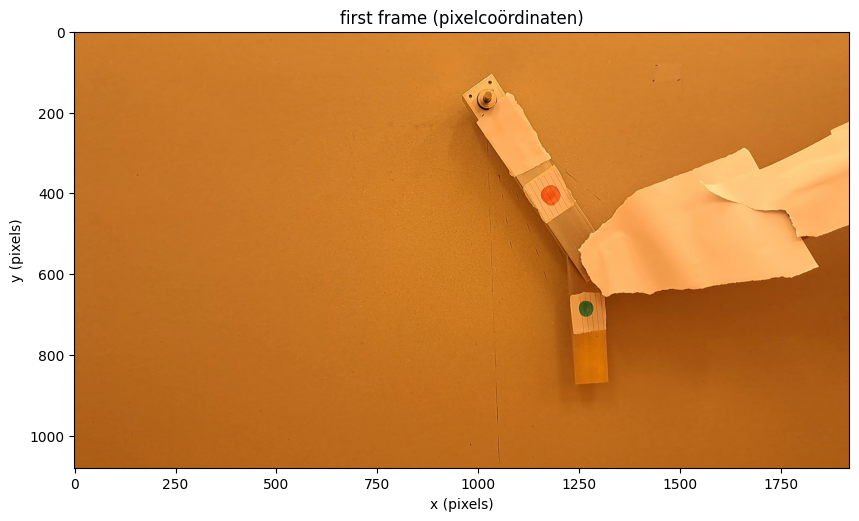

WindowsPath('first_frame_30A.png')

In [48]:
export_first_frame(
    video_path="../videos/30_A.mp4",
    output_png="first_frame_30A.png",
    show=True,          # shows the frame with pixel axes; hover to read coordinates
)



[A] tracking van 30_A.mp4 ...
Preview gesloten bij frame 25; tracking gaat door zonder preview.
Saved ..\data\30_A_2markers.csv: 324 frames, fps = 30.00
Missende detecties: marker 1 (red) = 66, marker 2 (green) = 4
[A] r1 = 6.83 ± 0.08 cm (L1 = 12.8),  r2 = 6.93 ± 0.12 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\30_A_canonical.csv
[B] tracking van 30_B.mp4 ...
Preview gesloten bij frame 129; tracking gaat door zonder preview.
Saved ..\data\30_B_2markers.csv: 343 frames, fps = 30.00
Missende detecties: marker 1 (red) = 102, marker 2 (green) = 5
[B] r1 = 6.86 ± 0.33 cm (L1 = 12.8),  r2 = 6.89 ± 0.34 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\30_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 0.995 s,  B = 0.833 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   33.19°, phi2_0 =   18.51°   U0 = 103.56 mJ
  B: phi1_0 =   32.15°, phi2_0 =   17.24°   U0 = 96.80 mJ
  U0 (gemiddeld A, B) = 100.18 mJ  = 0.068 U_max;   gemeten E(tau<0.1 s) in A = 88.95 mJ
To

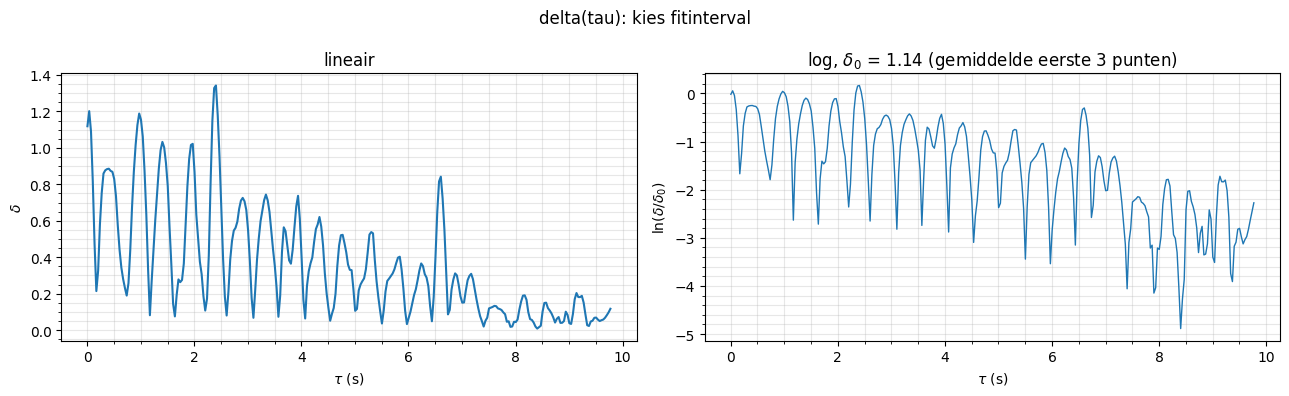

In [ ]:
# running the first pair
vA = "../videos/30_A.mp4"
vB = "../videos/30_B.mp4"   # same release, about 3° larger theta1

norm = dict(phi_n=1, p1_n=0.01134, p2_n=0.0034878)    # your choice, report these values

r = analyse_pair(vA, vB,t_release_A = 0.995,t_release_B = 0.833,out_dir="../data",retrack=True,norm=norm)

[A] tracking van 40_A.mp4 ...
Preview gesloten bij frame 21; tracking gaat door zonder preview.
Saved ..\data\40_A_2markers.csv: 324 frames, fps = 30.00
Missende detecties: marker 1 (red) = 66, marker 2 (green) = 4
[A] r1 = 6.93 ± 0.07 cm (L1 = 12.9),  r2 = 6.98 ± 0.12 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\40_A_canonical.csv
[B] tracking van 40_B.mp4 ...
Preview gesloten bij frame 21; tracking gaat door zonder preview.
Saved ..\data\40_B_2markers.csv: 343 frames, fps = 30.00
Missende detecties: marker 1 (red) = 102, marker 2 (green) = 5
[B] r1 = 6.96 ± 0.33 cm (L1 = 12.9),  r2 = 6.95 ± 0.34 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\40_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 1.000 s,  B = 0.833 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   32.52°, phi2_0 =   18.57°   U0 = 100.55 mJ
  B: phi1_0 =   32.27°, phi2_0 =   17.24°   U0 = 98.19 mJ
  U0 (gemiddeld A, B) = 99.37 mJ  = 0.068 U_max;   gemeten E(tau<0.1 s) in A = 85.17 mJ
Toes

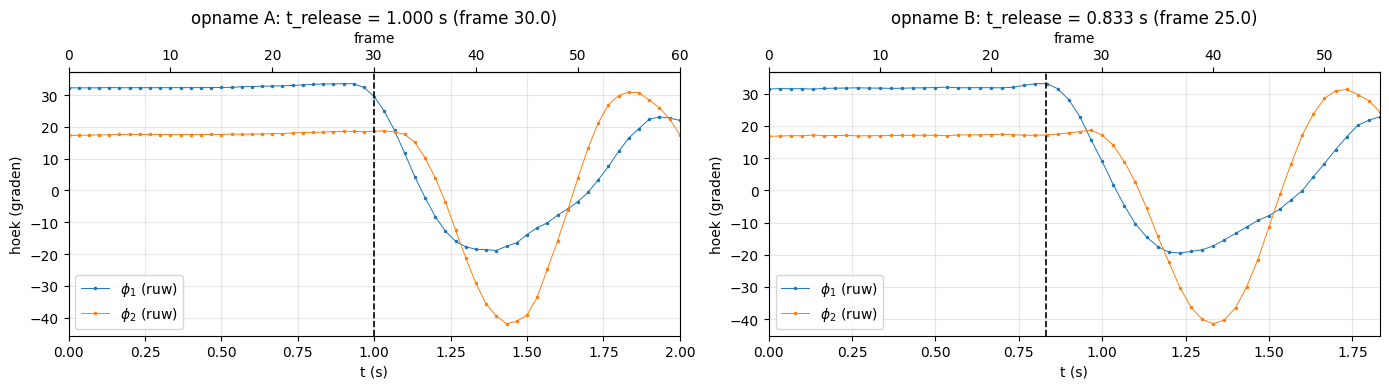

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.011426, p2_n=0.0034912)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [41]:
# running the first pair
vA = "../videos/40_A.mp4"
vB = "../videos/40_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 1.0,t_release_B = 0.833,out_dir="../data",retrack=True)

[A] tracking van 40_A.mp4 ...
Preview gesloten bij frame 62; tracking gaat door zonder preview.
Saved ..\data\40_A_2markers.csv: 324 frames, fps = 30.00
Missende detecties: marker 1 (red) = 66, marker 2 (green) = 4
[A] r1 = 6.93 ± 0.07 cm (L1 = 12.9),  r2 = 6.98 ± 0.12 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\40_A_canonical.csv
[B] tracking van 40_B.mp4 ...
Preview gesloten bij frame 53; tracking gaat door zonder preview.
Saved ..\data\40_B_2markers.csv: 343 frames, fps = 30.00
Missende detecties: marker 1 (red) = 102, marker 2 (green) = 5
[B] r1 = 6.96 ± 0.33 cm (L1 = 12.9),  r2 = 6.95 ± 0.34 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\40_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 0.933 s,  B = 0.895 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   33.43°, phi2_0 =   18.40°   U0 = 105.57 mJ
  B: phi1_0 =   32.47°, phi2_0 =   17.23°   U0 = 99.31 mJ
  U0 (gemiddeld A, B) = 102.44 mJ  = 0.070 U_max;   gemeten E(tau<0.1 s) in A = 100.57 mJ
To

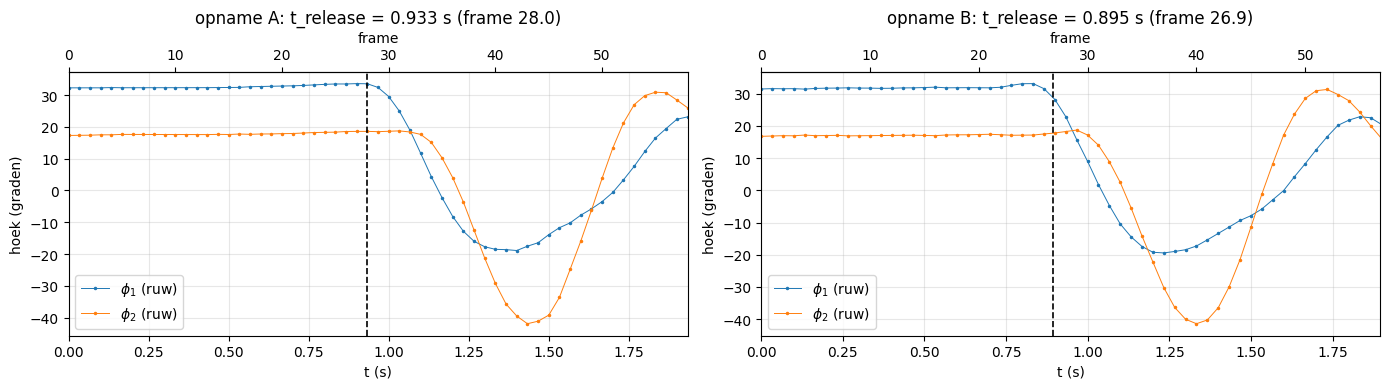

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.011411, p2_n=0.0034802)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [42]:
#running second pair
vA = "../videos/40_A.mp4"
vB = "../videos/40_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 0.933,t_release_B = 0.895,out_dir="../data",retrack=True)

[A] tracking van 50_A.mp4 ...
Preview gesloten bij frame 100; tracking gaat door zonder preview.
Saved ..\data\50_A_2markers.csv: 403 frames, fps = 30.00
Missende detecties: marker 1 (red) = 70, marker 2 (green) = 22
[A] r1 = 6.99 ± 0.35 cm (L1 = 12.9),  r2 = 6.84 ± 0.43 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\50_A_canonical.csv
[B] tracking van 50_B.mp4 ...
Saved ..\data\50_B_2markers.csv: 459 frames, fps = 30.00
Missende detecties: marker 1 (red) = 110, marker 2 (green) = 30
[B] r1 = 6.91 ± 0.09 cm (L1 = 12.9),  r2 = 6.88 ± 0.33 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\50_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 1.385 s,  B = 2.133 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   39.45°, phi2_0 =   20.84°   U0 = 144.67 mJ
  B: phi1_0 =   41.21°, phi2_0 =   21.33°   U0 = 156.99 mJ
  U0 (gemiddeld A, B) = 150.83 mJ  = 0.103 U_max;   gemeten E(tau<0.1 s) in A = 125.24 mJ
Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten

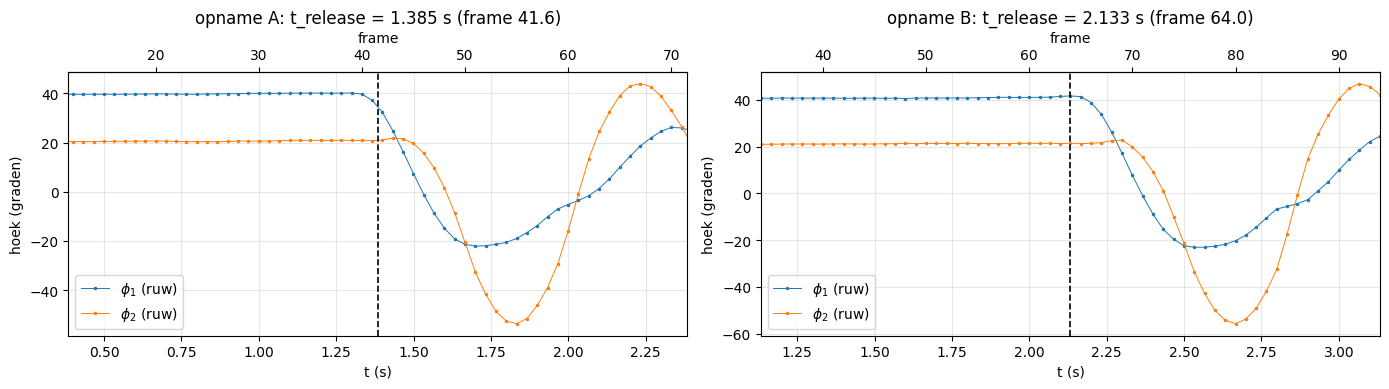

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.01316, p2_n=0.0040221)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [43]:
# running the third pair
vA = "../videos/50_A.mp4"
vB = "../videos/50_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 1.385,t_release_B = 2.133,out_dir="../data",retrack=True)

[A] tracking van 60_A.mp4 ...
Saved ..\data\60_A_2markers.csv: 472 frames, fps = 30.00
Missende detecties: marker 1 (red) = 167, marker 2 (green) = 62
[A] r1 = 7.07 ± 0.23 cm (L1 = 12.9),  r2 = 6.62 ± 0.91 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\60_A_canonical.csv
[B] tracking van 60_B.mp4 ...
Saved ..\data\60_B_2markers.csv: 450 frames, fps = 30.00
Missende detecties: marker 1 (red) = 133, marker 2 (green) = 58
[B] r1 = 7.08 ± 0.20 cm (L1 = 12.9),  r2 = 6.73 ± 0.80 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\60_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 1.300 s,  B = 1.200 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   52.23°, phi2_0 =   26.46°   U0 = 245.24 mJ
  B: phi1_0 =   56.38°, phi2_0 =   24.94°   U0 = 278.69 mJ
  U0 (gemiddeld A, B) = 261.96 mJ  = 0.179 U_max;   gemeten E(tau<0.1 s) in A = 198.01 mJ
Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten dicht bij elkaar liggen:
           phi1 (deg)  phi2 (deg)       

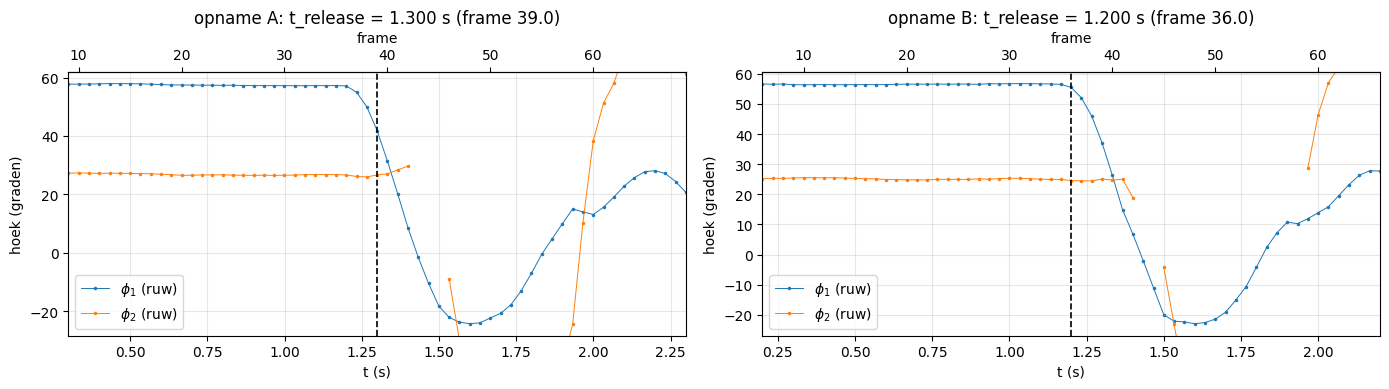

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.015553, p2_n=0.0048902)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [44]:
#running the fourth pair
vA = "../videos/60_A.mp4"
vB = "../videos/60_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 1.233,t_release_B = 1.200,out_dir="../data",retrack=True)

[A] tracking van 70_A.mp4 ...
Saved ..\data\70_A_2markers.csv: 432 frames, fps = 30.00
Missende detecties: marker 1 (red) = 148, marker 2 (green) = 48
[A] r1 = 7.02 ± 0.24 cm (L1 = 12.9),  r2 = 6.32 ± 1.50 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\70_A_canonical.csv
[B] tracking van 70_B.mp4 ...
Saved ..\data\70_B_2markers.csv: 501 frames, fps = 30.00
Missende detecties: marker 1 (red) = 203, marker 2 (green) = 48
[B] r1 = 7.06 ± 0.30 cm (L1 = 12.9),  r2 = 6.35 ± 1.24 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\70_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 1.000 s,  B = 0.833 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =  -17.81°, phi2_0 =  -35.22°   U0 = 53.72 mJ
  B: phi1_0 =   68.88°, phi2_0 =   33.89°   U0 = 404.43 mJ
  U0 (gemiddeld A, B) = 229.08 mJ  = 0.156 U_max;   gemeten E(tau<0.1 s) in A = 208.98 mJ
Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten dicht bij elkaar liggen:
           phi1 (deg)  phi2 (deg)        

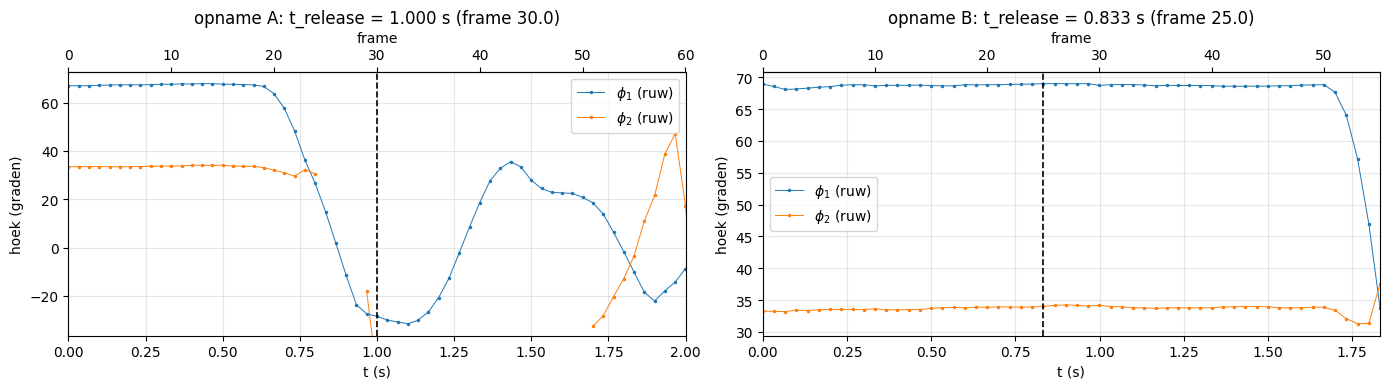

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.012212, p2_n=0.0036546)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [45]:
# running the fifth pair
vA = "../videos/70_A.mp4"
vB = "../videos/70_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 1.0,t_release_B = 1.800,out_dir="../data",retrack=True)

[A] tracking van 80_A.mp4 ...
Saved ..\data\80_A_2markers.csv: 665 frames, fps = 30.00
Missende detecties: marker 1 (red) = 129, marker 2 (green) = 174
[A] r1 = 6.88 ± 0.16 cm (L1 = 12.8),  r2 = 6.34 ± 1.20 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\80_A_canonical.csv
[B] tracking van 80_B.mp4 ...
Saved ..\data\80_B_2markers.csv: 444 frames, fps = 29.74
Missende detecties: marker 1 (red) = 220, marker 2 (green) = 64
[B] r1 = 6.85 ± 0.27 cm (L1 = 12.8),  r2 = 5.91 ± 1.64 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\80_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 2.566 s,  B = 1.800 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   -2.59°, phi2_0 =   19.07°   U0 = 8.15 mJ
  B: phi1_0 =   40.63°, phi2_0 =   25.29°   U0 = 155.68 mJ
  U0 (gemiddeld A, B) = 81.92 mJ  = 0.056 U_max;   gemeten E(tau<0.1 s) in A = 196.52 mJ
Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten dicht bij elkaar liggen:
           phi1 (deg)  phi2 (deg)       p1

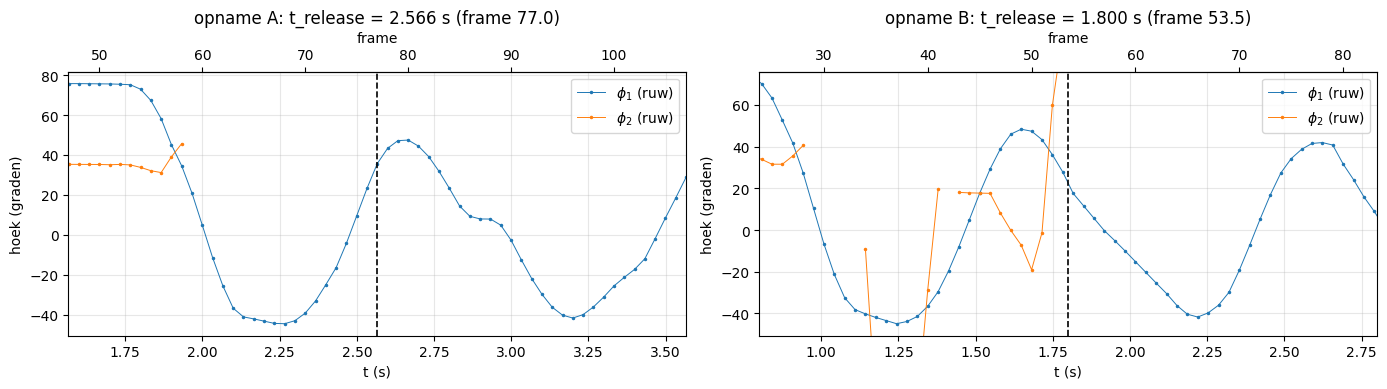

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.025394, p2_n=0.0079214)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [53]:
# running the fifth pair
vA = "../videos/80_A.mp4"
vB = "../videos/80_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 2.566,t_release_B = 1.800,out_dir="../data",retrack=True)

[A] tracking van 90_A.mp4 ...
Saved ..\data\90_A_2markers.csv: 472 frames, fps = 30.00
Missende detecties: marker 1 (red) = 157, marker 2 (green) = 90
[A] r1 = 6.82 ± 0.29 cm (L1 = 12.8),  r2 = 5.78 ± 1.49 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\90_A_canonical.csv
[B] tracking van 90_B.mp4 ...
Saved ..\data\90_B_2markers.csv: 472 frames, fps = 30.00
Missende detecties: marker 1 (red) = 156, marker 2 (green) = 97
[B] r1 = 6.86 ± 0.40 cm (L1 = 12.8),  r2 = 5.99 ± 1.54 cm (L2 = 7.0)
Canonieke CSV opgeslagen: ..\data\90_B_canonical.csv

=== Beginvoorwaarden ===
Loslaatmoment:  A = 1.600 s,  B = 1.700 s
Beginhoeken (gem. over 5 frames vóór loslaten):
  A: phi1_0 =   72.55°, phi2_0 =   56.17°   U0 = 474.77 mJ
  B: phi1_0 =  -40.05°, phi2_0 =   11.46°   U0 = 141.33 mJ
  U0 (gemiddeld A, B) = 308.05 mJ  = 0.210 U_max;   gemeten E(tau<0.1 s) in A = 509.20 mJ
Toestand na uitlijnen/bijsnijden (gladgestreken) — A en B moeten dicht bij elkaar liggen:
           phi1 (deg)  phi2 (deg)       

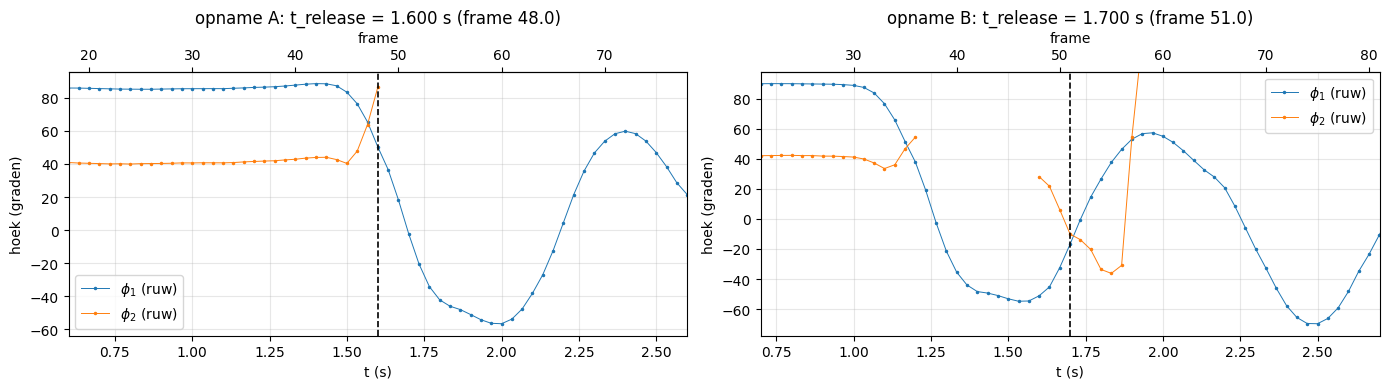

Voorgestelde schalen (alleen ter indicatie):
  norm = dict(phi_n=3.1416, p1_n=0.0227, p2_n=0.0053294)
    Roep opnieuw aan met norm=dict(phi_n=..., p1_n=..., p2_n=...).


In [54]:
# running the fifth pair
vA = "../videos/90_A.mp4"
vB = "../videos/90_B.mp4"   # same release, about 3° larger theta1

r = analyse_pair(vA, vB,t_release_A = 1.600,t_release_B = 1.700,out_dir="../data",retrack=True)